# **Pearls AQI Predictor — Exploratory Data Analysis (EDA)**

**City:** Bahawalpur, Pakistan

**Goal:** Look at the real historical data to understand patterns —
does pollution change by hour of day? By month/season? Which pollutants move together?
This is the same data used to train the models, we're just looking at it visually here.

This notebook reuses the same `connect_to_hopsworks()` / `get_or_create_feature_group()`
functions from `src/hopsworks_connection.py` — no duplicated connection logic.

In [1]:
import sys
sys.path.append('..')  # so we can import from src/ if notebook is inside a subfolder

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from src.hopsworks_connection import connect_to_hopsworks, get_or_create_feature_group

load_dotenv()

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

Matplotlib is building the font cache; this may take a moment.
/home/abdul-wahab/Downloads/aqi-predictor/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **1. Load the data**

Pulling the full dataset straight from Hopsworks — same source of truth the training pipeline uses.

In [2]:
project = connect_to_hopsworks()
fg = get_or_create_feature_group(project)
df = fg.read()
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

2026-08-07 14:07:26,237 INFO: Initializing external client
2026-08-07 14:07:26,238 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-07 14:07:30,757 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41129
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (13.71s) 
Total rows: 17500
Date range: 2024-07-27 00:00:00 to 2026-08-07 08:13:04.908733


,city,timestamp,hour,day_of_week,month,pm2_5,pm10,aqi_pm25,aqi_pm10,overall_aqi
0,bahawalpur,2024-07-27 00:00:00,0,5,7,40.9,174.6,114,111,114
1,bahawalpur,2024-07-27 01:00:00,1,5,7,41.4,149.5,116,97,116
2,bahawalpur,2024-07-27 02:00:00,2,5,7,45.4,162.1,125,104,125
3,bahawalpur,2024-07-27 03:00:00,3,5,7,45.9,173.7,127,110,127
4,bahawalpur,2024-07-27 04:00:00,4,5,7,41.6,142.5,116,94,116


In [3]:
df.head(20)

,city,timestamp,hour,day_of_week,month,pm2_5,pm10,aqi_pm25,aqi_pm10,overall_aqi
0,bahawalpur,2024-07-27 00:00:00,0,5,7,40.9,174.6,114,111,114
1,bahawalpur,2024-07-27 01:00:00,1,5,7,41.4,149.5,116,97,116
2,bahawalpur,2024-07-27 02:00:00,2,5,7,45.4,162.1,125,104,125
3,bahawalpur,2024-07-27 03:00:00,3,5,7,45.9,173.7,127,110,127
4,bahawalpur,2024-07-27 04:00:00,4,5,7,41.6,142.5,116,94,116
5,bahawalpur,2024-07-27 05:00:00,5,5,7,37.7,118.5,106,82,106
6,bahawalpur,2024-07-27 06:00:00,6,5,7,34.8,112.2,99,79,99
7,bahawalpur,2024-07-27 07:00:00,7,5,7,33.9,131.8,97,89,97
8,bahawalpur,2024-07-27 08:00:00,8,5,7,34.8,159.3,99,103,103
9,bahawalpur,2024-07-27 09:00:00,9,5,7,35.5,176.5,101,112,112


## **2. Quick look at the data**

Basic stats — min, max, average for each column. Good for spotting anything obviously wrong
(like negative values or impossible numbers) before trusting the charts below.

In [4]:
df[['pm2_5', 'pm10', 'aqi_pm25', 'aqi_pm10', 'overall_aqi']].describe()

,pm2_5,pm10,aqi_pm25,aqi_pm10,overall_aqi
count,17500.000000,17500.000000,17500.000000,17500.000000,17500.000000
mean,51.008233,84.279242,118.105714,62.755143,118.908171
std,36.401436,59.825278,44.436736,35.084604,46.565236
min,1.500000,1.600000,6.000000,1.000000,6.000000
25%,26.800000,44.900000,82.000000,41.000000,82.000000
50%,39.950000,69.600000,112.000000,58.000000,112.000000
75%,62.450000,105.900000,155.000000,76.000000,155.000000
max,291.500000,704.100000,334.000000,500.000000,500.000000


## **3. Does AQI change by hour of day?**

average the AQI for each hour (0–23) across the whole dataset, and plot it.
This shows if pollution is worse at certain times of day (e.g. morning traffic, night cooling).

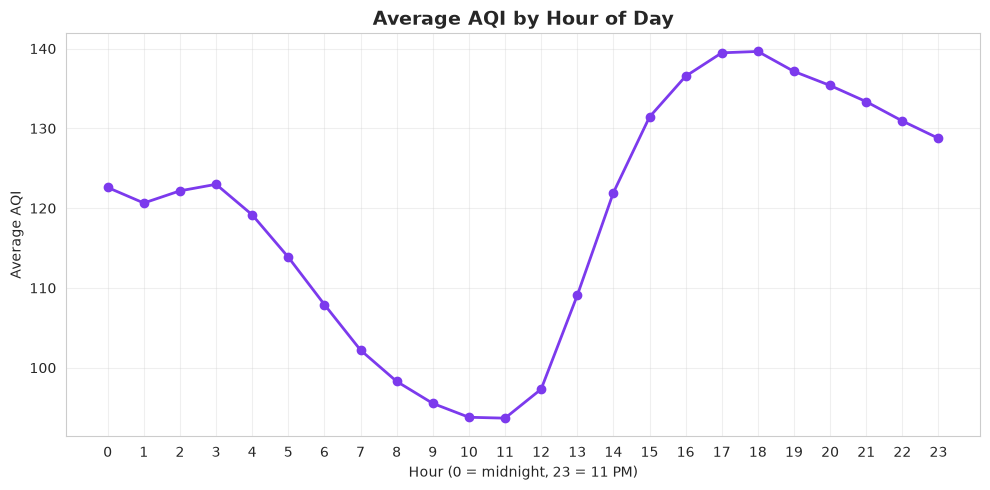

In [5]:
hourly_avg = df.groupby('hour')['overall_aqi'].mean()

plt.figure(figsize=(10, 5))

# hourly_avg.index -> labels (hours)
# hourly_avg.values -> values (overall_aqi)
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='#7c3aed', linewidth=2)
plt.title('Average AQI by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (0 = midnight, 23 = 11 PM)')
plt.ylabel('Average AQI')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **4. Does AQI change by month (season)?**

Now grouped by month instead of hour.
Bahawalpur is a desert city — we expect winter (smog) and summer (dust storms)
to look different. This chart should show that pattern directly in the real data.

2026-08-07 14:28:40,655 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-07 14:28:40,658 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


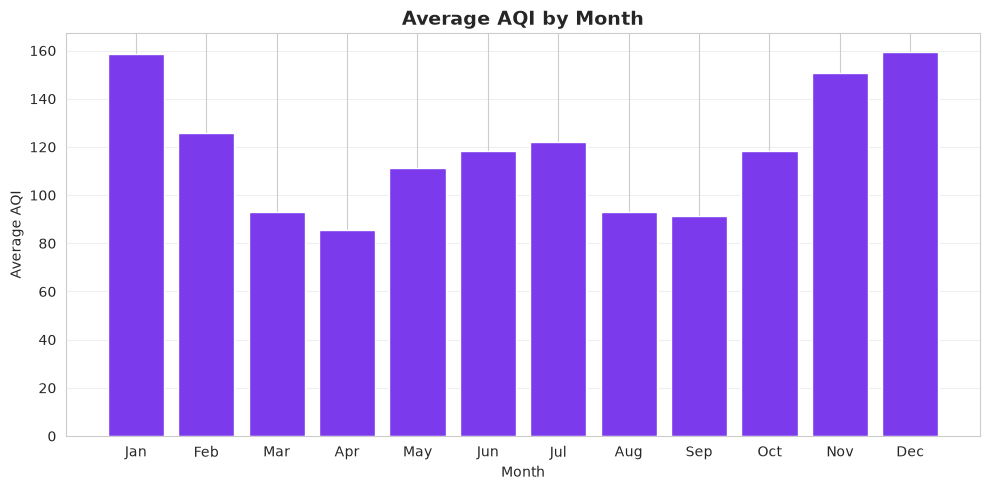

In [6]:
monthly_avg = df.groupby('month')['overall_aqi'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] # start from 0

plt.figure(figsize=(10, 5))
bars = plt.bar([month_names[m-1] for m in monthly_avg.index], monthly_avg.values, color='#7c3aed')
plt.title('Average AQI by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## **5. Winter vs Summer — the seasonal story**

split the data into two groups — winter months (Nov–Feb, smog season)
and summer months (May–Aug, dust storm season) — and compare their AQI distributions
side by side. This is the exact pattern that caused the negative R² problem during
model training (train/test split crossing season boundaries).

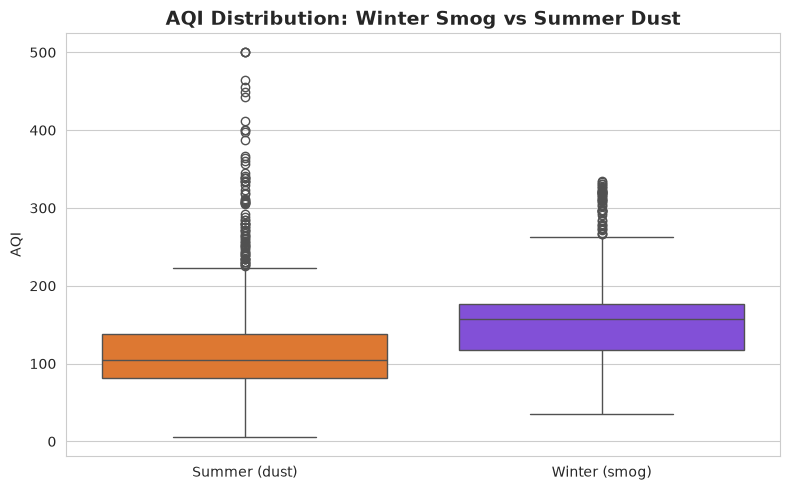

                     mean        std   min    max
season                                           
Summer (dust)  110.925731  42.332018   6.0  500.0
Winter (smog)  149.181771  44.362868  35.0  334.0


In [7]:
winter_months = [11, 12, 1, 2]
summer_months = [5, 6, 7, 8]

df['season'] = df['month'].apply(
    lambda m: 'Winter (smog)' if m in winter_months else ('Summer (dust)' if m in summer_months else 'Other')
)

season_df = df[df['season'] != 'Other'] # remove other months

plt.figure(figsize=(8, 5))
sns.boxplot(data=season_df, x='season', y='overall_aqi', hue='season', palette=['#f97316', '#7c3aed'], legend=False)
plt.title('AQI Distribution: Winter Smog vs Summer Dust', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

print(season_df.groupby('season')['overall_aqi'].describe()[['mean', 'std', 'min', 'max']])

## **6. Which pollutants move together? (Correlation)**

a correlation heatmap shows which columns rise and fall together.
This helps confirm our features actually make sense (e.g. `pm10` and `aqi_pm10` should
be strongly correlated, since one is calculated directly from the other).

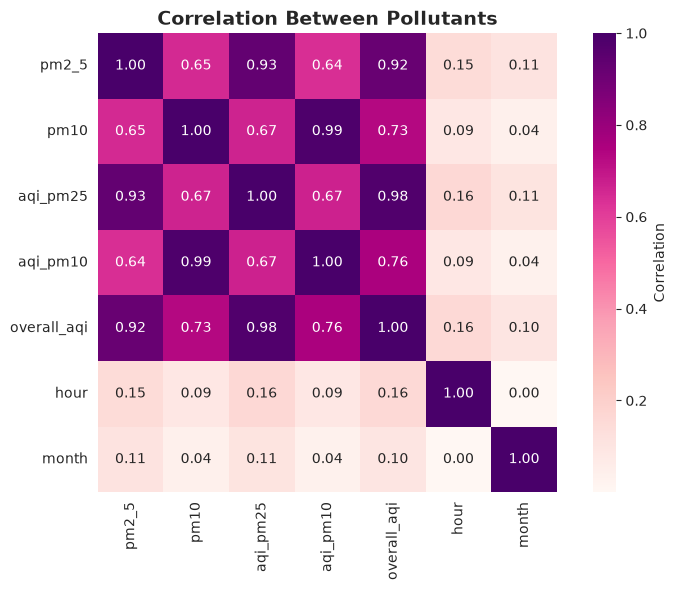

In [8]:
corr_cols = ['pm2_5', 'pm10', 'aqi_pm25', 'aqi_pm10', 'overall_aqi', 'hour', 'month']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdPu', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Pollutants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **7. The dust storm event (2026-06-11)**

- At june 11, 2026 AQI jumps upto 650+ and than I capped at AQI 500.
- (PM10 readings of 685–704, capped at AQI 500).
- This known extreme dust strom event and the chart confirms the event is
really in the data and shows what it looked like hour by hour.

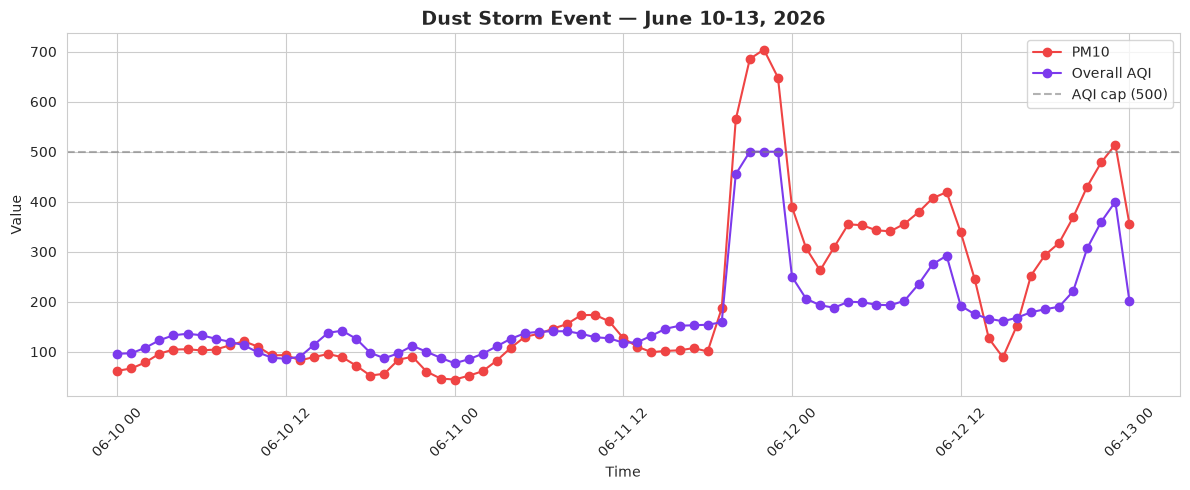

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
storm_window = df[(df['timestamp'] >= '2026-06-10') & (df['timestamp'] <= '2026-06-13')]

plt.figure(figsize=(12, 5))
plt.plot(storm_window['timestamp'], storm_window['pm10'], marker='o', color='#ef4444', label='PM10')
plt.plot(storm_window['timestamp'], storm_window['overall_aqi'], marker='o', color='#7c3aed', label='Overall AQI')
plt.axhline(y=500, color='gray', linestyle='--', alpha=0.6, label='AQI cap (500)')
plt.title('Dust Storm Event — June 10-13, 2026', fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Summary — what this notebook shows**

- **Hourly pattern:** AQI peaks around X AM/PM
- **Monthly/seasonal pattern:** confirms winter smog vs summer dust storm regimes are
  genuinely different, which is why the model needed 2 years of data and derived
  features to handle both seasons.
- **Correlation:** `pm10`/`aqi_pm10` and `pm2_5`/`aqi_pm25` are strongly correlated
  (expected, since AQI is calculated directly from the pollutant readings).
- **Dust storm case study:** confirms the extreme June 2026 event is real, in the data,
  and correctly capped at AQI 500 rather than dropped or crashing the pipeline.